# Sales Insights for Consumer Business

**Author:** Goodluck Badewole

## Project Overview

This project analyzes sales transaction data for a consumer electronics business to uncover actionable business insights. Using Python connected with SQL (SQLite), we perform exploratory data analysis and create visualizations to support data-informed decision-making.

### Objectives
- Analyze revenue trends over a 5-year period (2019-2023)
- Identify top-performing customers, products, and markets
- Examine seasonal patterns and year-over-year growth
- Assess profit margins across different product types and markets
- Provide actionable business recommendations

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Color palette
COLORS = {
    'primary': '#2196F3',
    'secondary': '#4CAF50',
    'accent': '#FF9800',
    'danger': '#F44336',
    'purple': '#9C27B0',
    'teal': '#009688'
}
PALETTE = list(COLORS.values())

print('Setup complete.')

Setup complete.


## 2. Data Loading & SQL Database Setup

We load the CSV files into an SQLite database to demonstrate SQL querying capabilities, then extract the data into pandas DataFrames for analysis.

In [2]:
# Load CSV files
customers_df = pd.read_csv('data/customers.csv')
products_df = pd.read_csv('data/products.csv')
markets_df = pd.read_csv('data/markets.csv')
transactions_df = pd.read_csv('data/sales_transactions.csv')

# Create SQLite database and load data
conn = sqlite3.connect(':memory:')

customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
markets_df.to_sql('markets', conn, index=False, if_exists='replace')
transactions_df.to_sql('transactions', conn, index=False, if_exists='replace')

print(f'Customers:    {len(customers_df)} records')
print(f'Products:     {len(products_df)} records')
print(f'Markets:      {len(markets_df)} records')
print(f'Transactions: {len(transactions_df)} records')

Customers:    50 records
Products:     20 records
Markets:      10 records
Transactions: 5000 records


In [3]:
# SQL: Join all tables into a master dataset
query = """
SELECT 
    t.transaction_id,
    t.date,
    t.quantity,
    t.sales_amount,
    t.cost_price,
    t.profit,
    c.customer_name,
    c.customer_type,
    p.product_name,
    p.product_type,
    m.market_name,
    m.zone
FROM transactions t
JOIN customers c ON t.customer_code = c.customer_code
JOIN products p ON t.product_code = p.product_code
JOIN markets m ON t.market_code = m.market_code
"""

df = pd.read_sql_query(query, conn)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['quarter'] = df['date'].dt.quarter

print(f'Master dataset: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Master dataset: 5000 rows x 16 columns


,transaction_id,date,quantity,sales_amount,cost_price,profit,customer_name,customer_type,product_name,product_type,market_name,zone,year,month,month_name,quarter
0,TXN00663,2019-01-01,14,228.62,102.88,125.74,Horizon Trading Co.,E-Commerce,Cable Management Kit,Own Brand,Denver,Central,2019,1,Jan,1
1,TXN02502,2019-01-01,4,36.76,16.54,20.22,Infinity Solutions,Brick & Mortar,HDMI Cable 6ft,Own Brand,Phoenix,West,2019,1,Jan,1
2,TXN03215,2019-01-01,2,26.66,12.00,14.66,Bright Retail,E-Commerce,USB-C Charging Cable,Own Brand,Dallas,South,2019,1,Jan,1
3,TXN03905,2019-01-01,1,98.32,63.91,34.41,Harbor Solutions,Brick & Mortar,Noise Cancelling Headphones,Distribution,Chicago,Central,2019,1,Jan,1
4,TXN04114,2019-01-01,4,220.68,99.31,121.37,Beacon Trading Co.,Brick & Mortar,Monitor Riser,Own Brand,Los Angeles,West,2019,1,Jan,1


## 3. Data Cleaning & Overview

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
transaction_id    0
date              0
quantity          0
sales_amount      0
cost_price        0
profit            0
customer_name     0
customer_type     0
product_name      0
product_type      0
market_name       0
zone              0
year              0
month             0
month_name        0
quarter           0
dtype: int64

Duplicate rows: 0


In [5]:
# Dataset summary statistics
print('=== Dataset Summary ===')
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total transactions: {len(df):,}")
print(f"Total revenue: ${df['sales_amount'].sum():,.2f}")
print(f"Total profit: ${df['profit'].sum():,.2f}")
print(f"Average profit margin: {(df['profit'].sum() / df['sales_amount'].sum() * 100):.1f}%")
print(f"Unique customers: {df['customer_name'].nunique()}")
print(f"Unique products: {df['product_name'].nunique()}")
print(f"Markets covered: {df['market_name'].nunique()}")
print()
df.describe().round(2)

=== Dataset Summary ===
Date range: 2019-01-01 to 2023-12-31
Total transactions: 5,000
Total revenue: $2,336,224.54
Total profit: $1,016,396.79
Average profit margin: 43.5%
Unique customers: 50
Unique products: 20
Markets covered: 10



,date,quantity,sales_amount,cost_price,profit,year,month,quarter
count,5000,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2021-06-27 05:49:20.639999744,13.50,467.24,263.97,203.28,2020.99,6.44,2.48
min,2019-01-01 00:00:00,1.00,8.11,4.23,2.84,2019.00,1.00,1.00
25%,2020-03-24 00:00:00,6.00,150.56,74.34,69.86,2020.00,3.00,1.00
50%,2021-06-20 00:00:00,12.00,324.48,163.51,149.61,2021.00,6.00,2.00
75%,2022-09-24 06:00:00,19.00,633.60,348.57,282.85,2022.00,9.00,3.00
max,2023-12-31 00:00:00,50.00,4082.96,2653.92,1518.28,2023.00,12.00,4.00
std,NaN,9.02,457.92,288.59,184.15,1.42,3.45,1.12


## 4. Exploratory Data Analysis

### 4.1 Revenue Trends Over Time

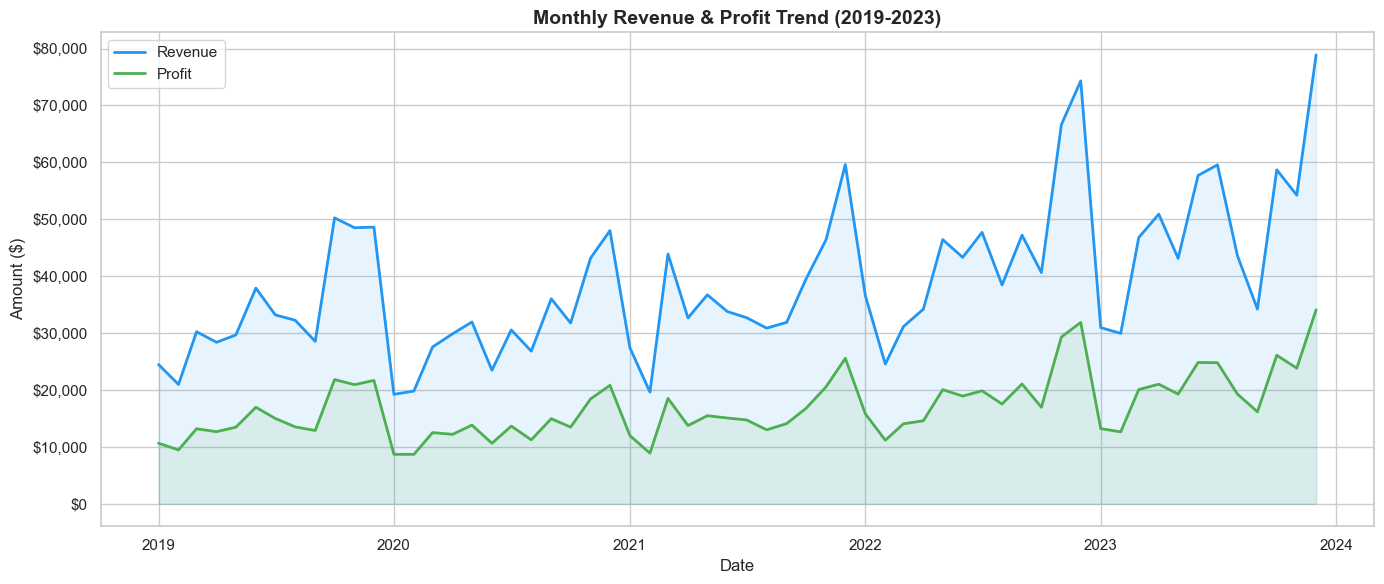

In [6]:
# Monthly revenue trend
monthly_revenue = df.groupby(df['date'].dt.to_period('M')).agg(
    revenue=('sales_amount', 'sum'),
    profit=('profit', 'sum')
).reset_index()
monthly_revenue['date'] = monthly_revenue['date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_revenue['date'], monthly_revenue['revenue'], 
        color=COLORS['primary'], linewidth=2, label='Revenue')
ax.plot(monthly_revenue['date'], monthly_revenue['profit'], 
        color=COLORS['secondary'], linewidth=2, label='Profit')
ax.fill_between(monthly_revenue['date'], monthly_revenue['revenue'], 
                alpha=0.1, color=COLORS['primary'])
ax.fill_between(monthly_revenue['date'], monthly_revenue['profit'], 
                alpha=0.1, color=COLORS['secondary'])

ax.set_title('Monthly Revenue & Profit Trend (2019-2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('assets/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

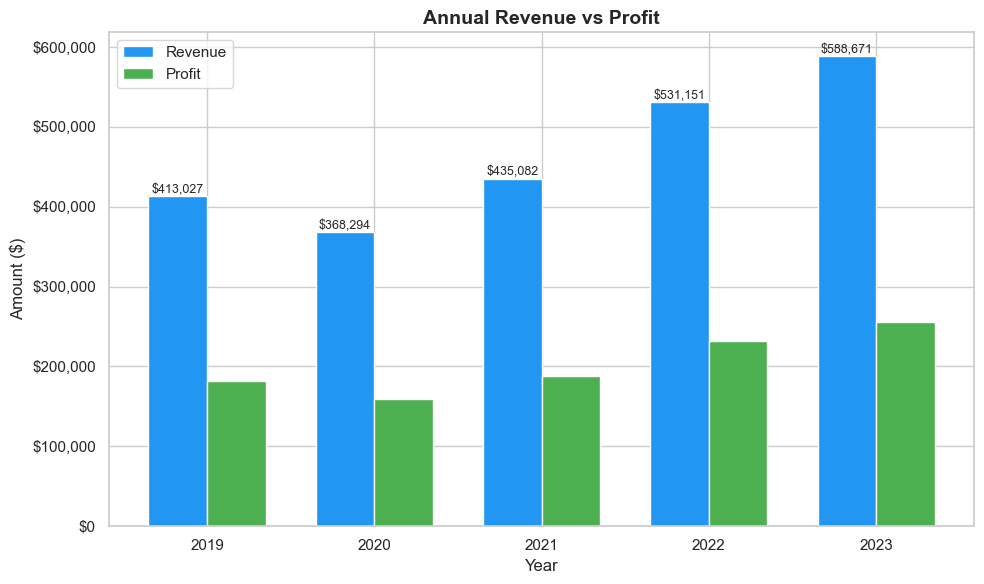

Year-over-Year Revenue Growth:
  2019: $413,027  (Baseline)
  2020: $368,294  (-10.8%)
  2021: $435,082  (+18.1%)
  2022: $531,151  (+22.1%)
  2023: $588,671  (+10.8%)


In [7]:
# Annual revenue comparison
yearly = df.groupby('year').agg(
    revenue=('sales_amount', 'sum'),
    profit=('profit', 'sum'),
    transactions=('transaction_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(yearly))
width = 0.35

bars1 = ax.bar(x - width/2, yearly['revenue'], width, 
               label='Revenue', color=COLORS['primary'], edgecolor='white')
bars2 = ax.bar(x + width/2, yearly['profit'], width, 
               label='Profit', color=COLORS['secondary'], edgecolor='white')

ax.set_title('Annual Revenue vs Profit')
ax.set_xlabel('Year')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(yearly['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('assets/annual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# YoY growth
yearly['revenue_growth'] = yearly['revenue'].pct_change() * 100
print('Year-over-Year Revenue Growth:')
for _, row in yearly.iterrows():
    growth = f"{row['revenue_growth']:+.1f}%" if pd.notna(row['revenue_growth']) else 'Baseline'
    print(f"  {int(row['year'])}: ${row['revenue']:,.0f}  ({growth})")

### 4.2 Top 10 Customers by Revenue

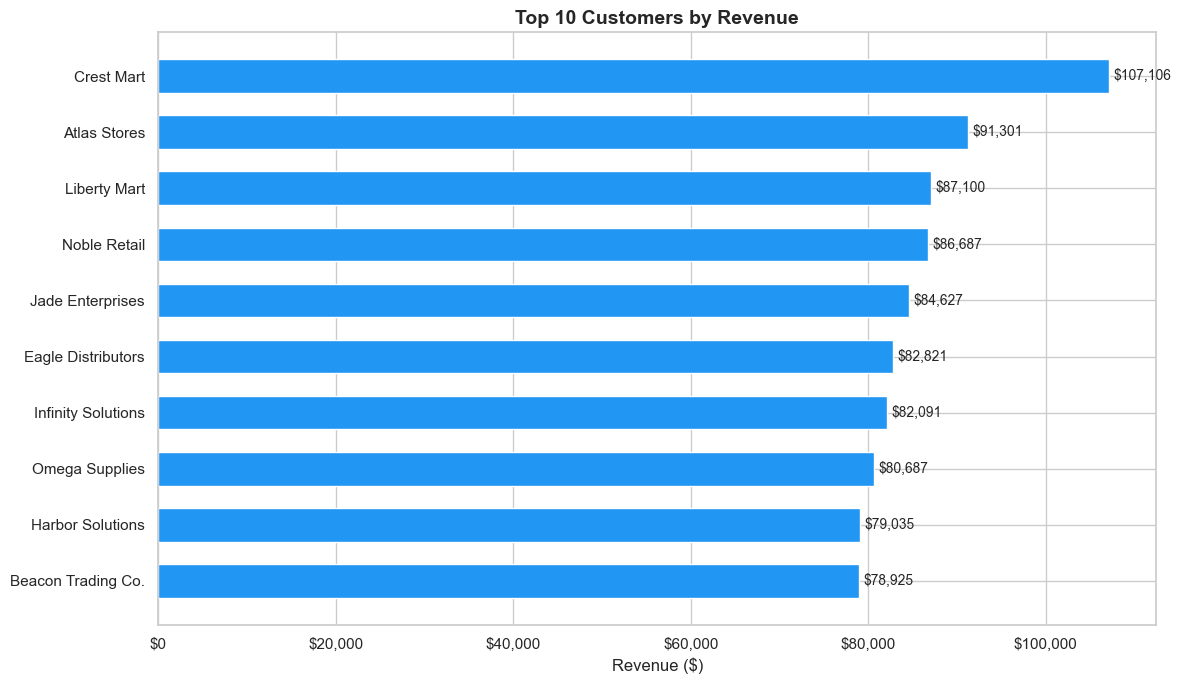

In [8]:
# Top 10 customers
top_customers = df.groupby('customer_name').agg(
    revenue=('sales_amount', 'sum'),
    profit=('profit', 'sum'),
    orders=('transaction_id', 'count')
).sort_values('revenue', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_customers.index, top_customers['revenue'], 
               color=COLORS['primary'], edgecolor='white', height=0.6)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}', ha='left', va='center', fontsize=10)

ax.set_title('Top 10 Customers by Revenue')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('assets/top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Sales by Market & Zone

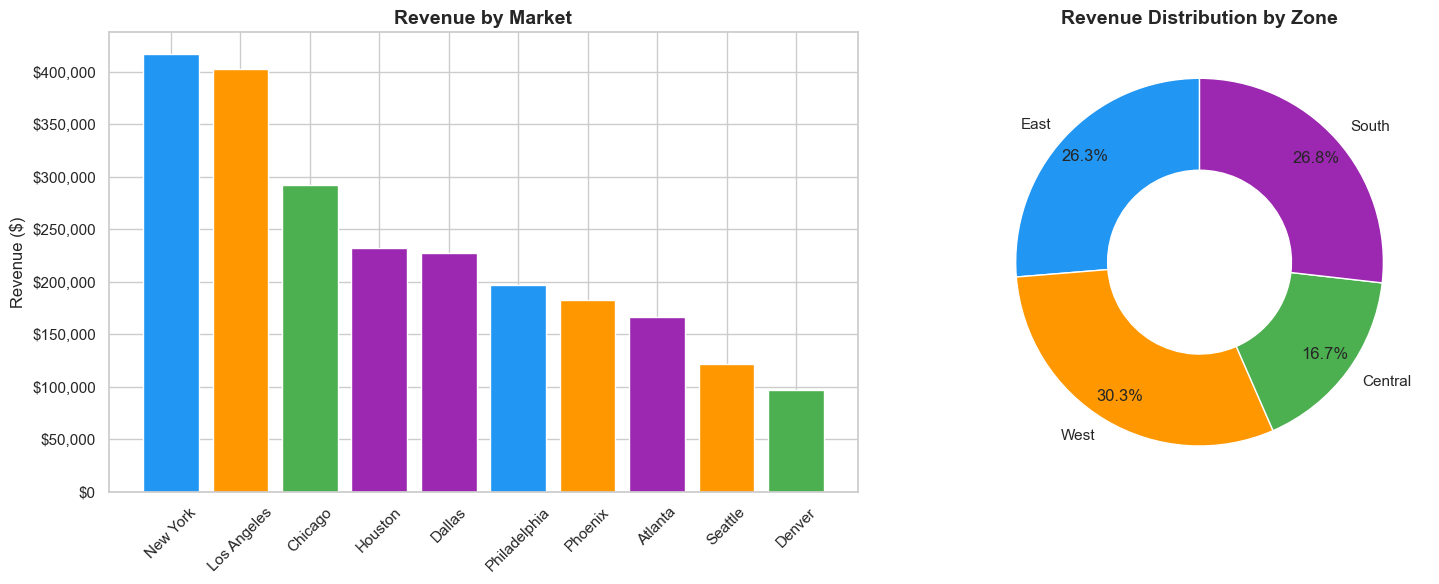

In [9]:
# Revenue by market
market_revenue = df.groupby(['market_name', 'zone'])['sales_amount'].sum().reset_index()
market_revenue = market_revenue.sort_values('sales_amount', ascending=False)

zone_colors = {'East': COLORS['primary'], 'West': COLORS['accent'], 
               'Central': COLORS['secondary'], 'South': COLORS['purple']}
bar_colors = [zone_colors[z] for z in market_revenue['zone']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - revenue by market
axes[0].bar(market_revenue['market_name'], market_revenue['sales_amount'], 
            color=bar_colors, edgecolor='white')
axes[0].set_title('Revenue by Market')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# Pie chart - revenue by zone
zone_revenue = df.groupby('zone')['sales_amount'].sum()
zone_order = ['East', 'West', 'Central', 'South']
zone_revenue = zone_revenue.reindex(zone_order)
pie_colors = [zone_colors[z] for z in zone_order]

wedges, texts, autotexts = axes[1].pie(
    zone_revenue, labels=zone_order, colors=pie_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.85,
    wedgeprops=dict(width=0.5, edgecolor='white')
)
axes[1].set_title('Revenue Distribution by Zone')

plt.tight_layout()
plt.savefig('assets/market_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Product Performance Analysis

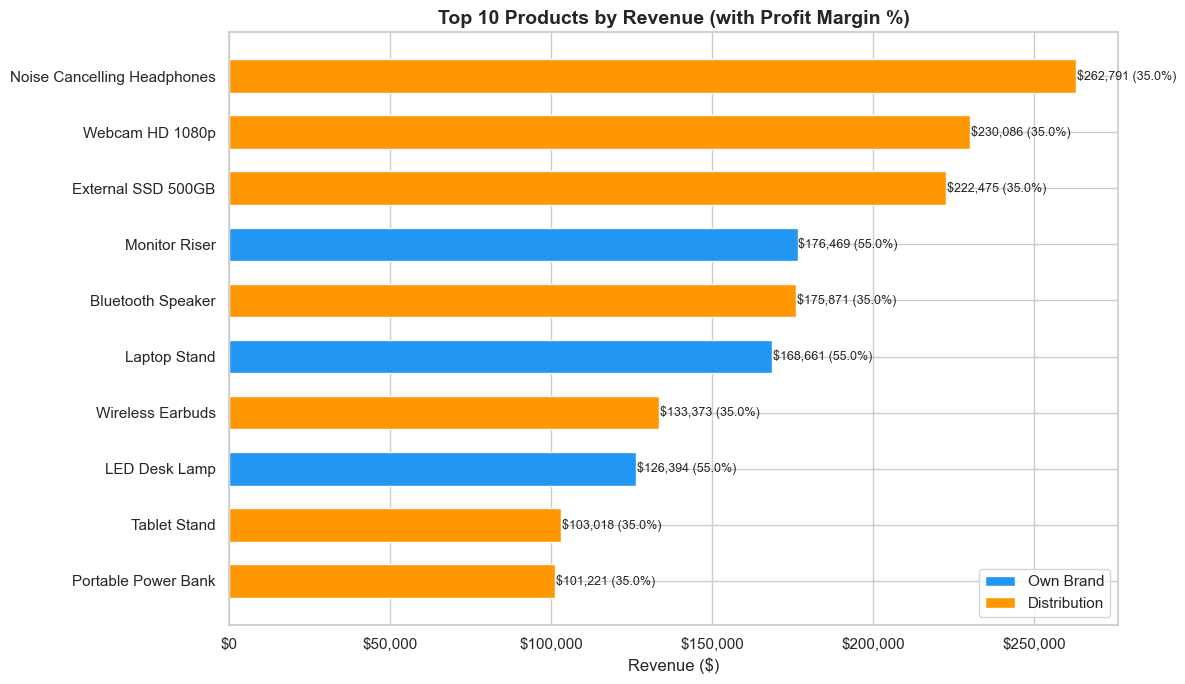

In [10]:
# Top 10 products by revenue
product_perf = df.groupby(['product_name', 'product_type']).agg(
    revenue=('sales_amount', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum')
).reset_index()
product_perf['margin'] = (product_perf['profit'] / product_perf['revenue'] * 100).round(1)
top_products = product_perf.sort_values('revenue', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [COLORS['primary'] if t == 'Own Brand' else COLORS['accent'] 
          for t in top_products['product_type']]
bars = ax.barh(top_products['product_name'], top_products['revenue'], 
               color=colors, edgecolor='white', height=0.6)

for bar, margin in zip(bars, top_products['margin']):
    width = bar.get_width()
    ax.text(width + 300, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f} ({margin}%)', ha='left', va='center', fontsize=9)

ax.set_title('Top 10 Products by Revenue (with Profit Margin %)')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['primary'], label='Own Brand'),
                   Patch(facecolor=COLORS['accent'], label='Distribution')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('assets/product_performance.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Monthly & Seasonal Trends

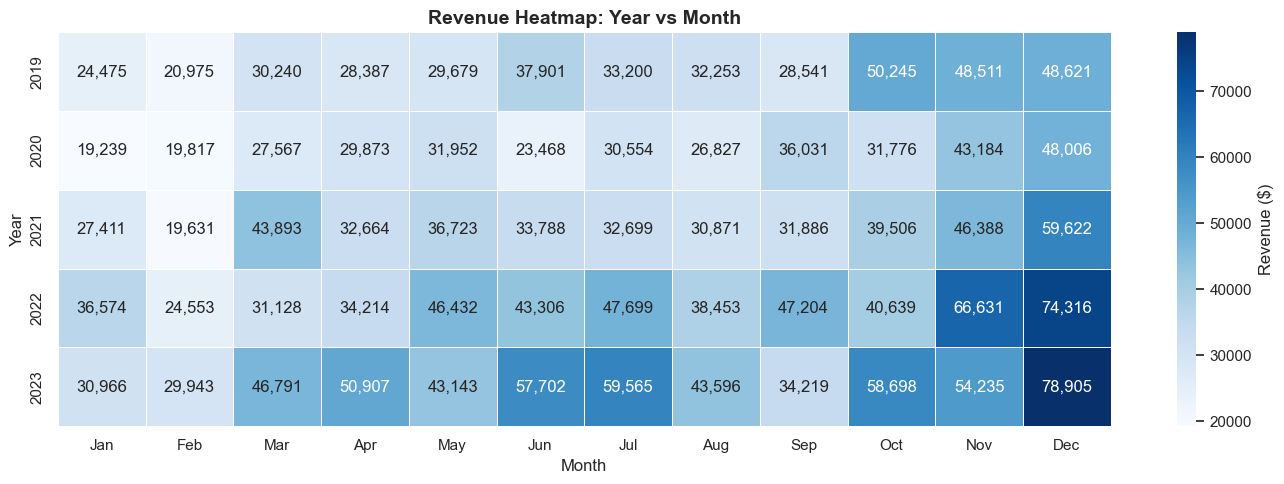

In [11]:
# Revenue heatmap: Year x Month
pivot = df.pivot_table(values='sales_amount', index='year', columns='month', aggfunc='sum')
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue ($)'})
ax.set_title('Revenue Heatmap: Year vs Month')
ax.set_ylabel('Year')
ax.set_xlabel('Month')
plt.tight_layout()
plt.savefig('assets/seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

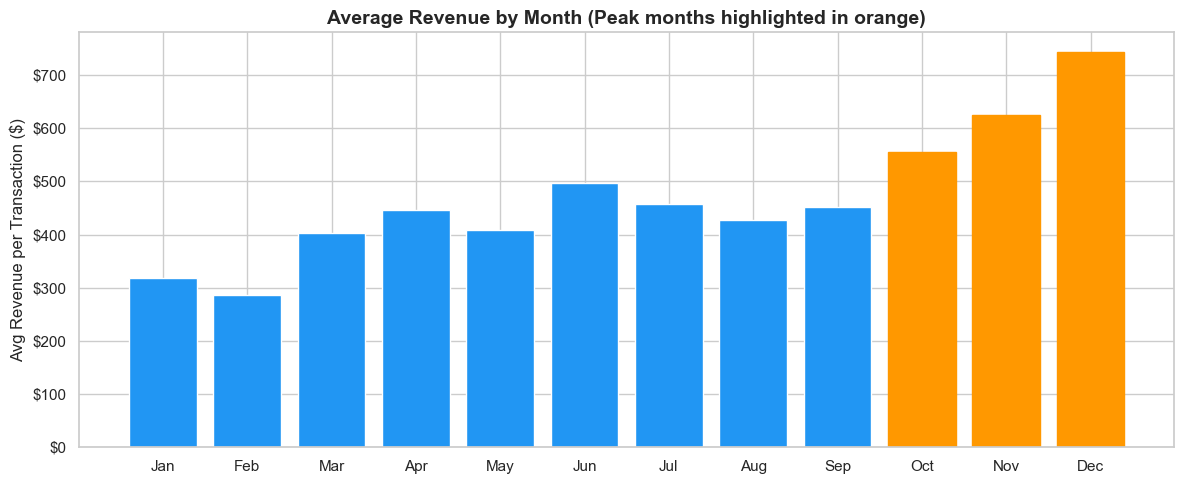

In [12]:
# Average monthly revenue pattern
monthly_avg = df.groupby('month')['sales_amount'].mean().reset_index()
monthly_avg['month_name'] = month_labels

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_avg['month_name'], monthly_avg['sales_amount'], 
              color=COLORS['primary'], edgecolor='white')

# Highlight peak months
peak_threshold = monthly_avg['sales_amount'].quantile(0.75)
for bar, val in zip(bars, monthly_avg['sales_amount']):
    if val >= peak_threshold:
        bar.set_color(COLORS['accent'])

ax.set_title('Average Revenue by Month (Peak months highlighted in orange)')
ax.set_ylabel('Avg Revenue per Transaction ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 4.6 Profit Margin Analysis

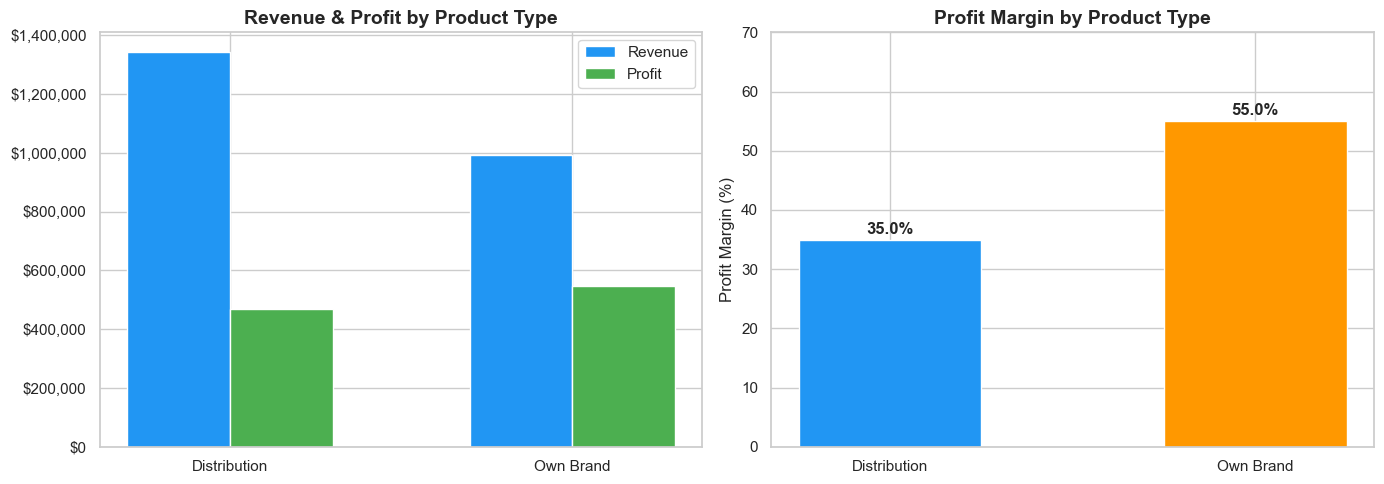


Product Type Performance:
  Distribution    | Revenue: $1,342,629.56 | Profit: $  469,919.96 | Margin: 35.0%
  Own Brand       | Revenue: $  993,594.98 | Profit: $  546,476.83 | Margin: 55.0%


In [13]:
# Profit margin: Own Brand vs Distribution
type_perf = df.groupby('product_type').agg(
    revenue=('sales_amount', 'sum'),
    profit=('profit', 'sum'),
    count=('transaction_id', 'count')
).reset_index()
type_perf['margin'] = (type_perf['profit'] / type_perf['revenue'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
x = np.arange(len(type_perf))
width = 0.3
axes[0].bar(x - width/2, type_perf['revenue'], width, label='Revenue', color=COLORS['primary'])
axes[0].bar(x + width/2, type_perf['profit'], width, label='Profit', color=COLORS['secondary'])
axes[0].set_title('Revenue & Profit by Product Type')
axes[0].set_xticks(x)
axes[0].set_xticklabels(type_perf['product_type'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend()

# Margin comparison
bar_colors = [COLORS['primary'], COLORS['accent']]
bars = axes[1].bar(type_perf['product_type'], type_perf['margin'], 
                   color=bar_colors, edgecolor='white', width=0.5)
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Profit Margin by Product Type')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_ylim(0, 70)

plt.tight_layout()
plt.savefig('assets/profit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nProduct Type Performance:')
for _, row in type_perf.iterrows():
    print(f"  {row['product_type']:15s} | Revenue: ${row['revenue']:>12,.2f} | Profit: ${row['profit']:>12,.2f} | Margin: {row['margin']}%")

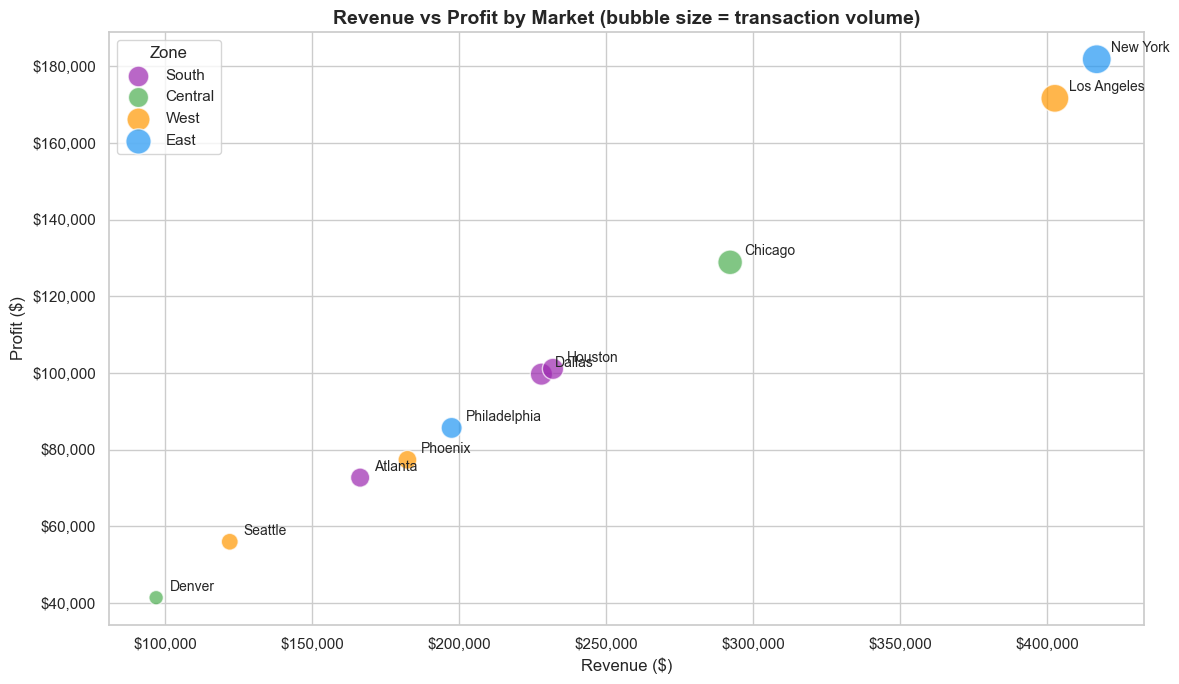

In [14]:
# Scatter: Revenue vs Profit by market (bubble = transaction count)
market_perf = df.groupby(['market_name', 'zone']).agg(
    revenue=('sales_amount', 'sum'),
    profit=('profit', 'sum'),
    count=('transaction_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
zone_colors_map = {'East': COLORS['primary'], 'West': COLORS['accent'], 
                   'Central': COLORS['secondary'], 'South': COLORS['purple']}

for zone in market_perf['zone'].unique():
    mask = market_perf['zone'] == zone
    subset = market_perf[mask]
    ax.scatter(subset['revenue'], subset['profit'], 
              s=subset['count'] * 0.5, alpha=0.7,
              color=zone_colors_map[zone], label=zone, edgecolors='white')
    
    for _, row in subset.iterrows():
        ax.annotate(row['market_name'], 
                   (row['revenue'], row['profit']),
                   textcoords='offset points', xytext=(10, 5), fontsize=10)

ax.set_title('Revenue vs Profit by Market (bubble size = transaction volume)')
ax.set_xlabel('Revenue ($)')
ax.set_ylabel('Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend(title='Zone')
plt.tight_layout()
plt.savefig('assets/market_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Customer Segmentation: Brick & Mortar vs E-Commerce

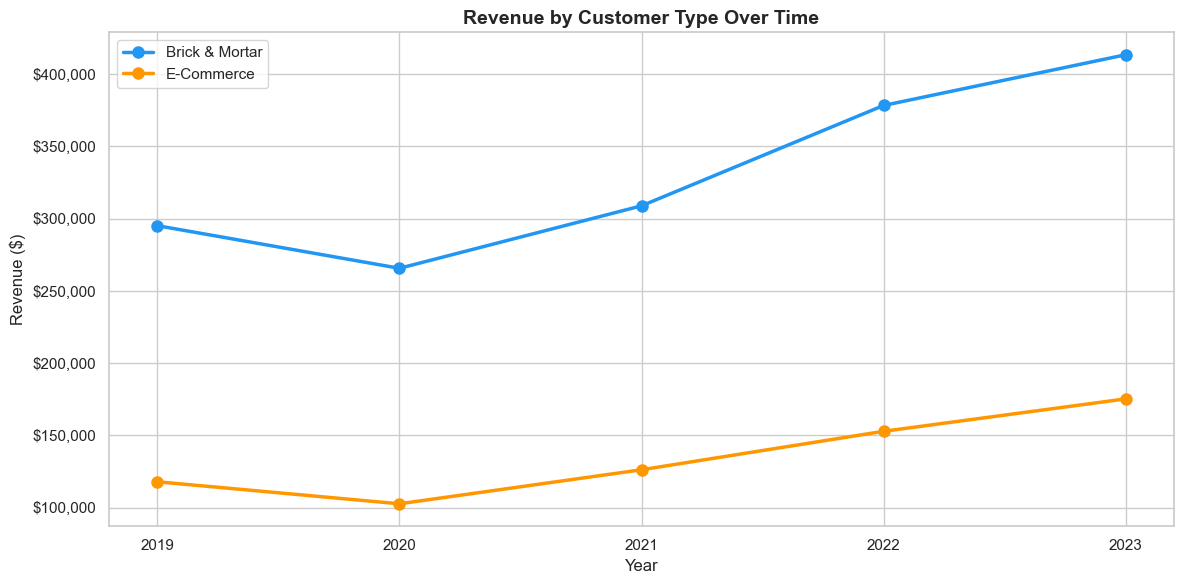

Customer Type Summary:


,total_revenue,avg_order,total_orders,unique_customers
customer_type,,,,
Brick & Mortar,1661420.09,468.93,3543,35
E-Commerce,674804.45,463.15,1457,15


In [15]:
# Customer type comparison over time
cust_type_yearly = df.groupby(['year', 'customer_type'])['sales_amount'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for ctype, color in zip(['Brick & Mortar', 'E-Commerce'], [COLORS['primary'], COLORS['accent']]):
    data = cust_type_yearly[cust_type_yearly['customer_type'] == ctype]
    ax.plot(data['year'], data['sales_amount'], marker='o', linewidth=2.5,
            markersize=8, color=color, label=ctype)

ax.set_title('Revenue by Customer Type Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend()
ax.set_xticks(cust_type_yearly['year'].unique())
plt.tight_layout()
plt.savefig('assets/customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
ctype_summary = df.groupby('customer_type').agg(
    total_revenue=('sales_amount', 'sum'),
    avg_order=('sales_amount', 'mean'),
    total_orders=('transaction_id', 'count'),
    unique_customers=('customer_name', 'nunique')
).round(2)
print('Customer Type Summary:')
ctype_summary

## 5. Key Insights & Recommendations

In [16]:
# Summary dashboard
total_revenue = df['sales_amount'].sum()
total_profit = df['profit'].sum()
avg_margin = total_profit / total_revenue * 100
total_txns = len(df)

# Calculate growth
rev_2019 = df[df['year'] == 2019]['sales_amount'].sum()
rev_2023 = df[df['year'] == 2023]['sales_amount'].sum()
overall_growth = ((rev_2023 - rev_2019) / rev_2019) * 100

# Top performers
top_customer = df.groupby('customer_name')['sales_amount'].sum().idxmax()
top_product = df.groupby('product_name')['sales_amount'].sum().idxmax()
top_market = df.groupby('market_name')['sales_amount'].sum().idxmax()

print('=' * 60)
print('        SALES INSIGHTS SUMMARY DASHBOARD')
print('=' * 60)
print(f'\n  Total Revenue:         ${total_revenue:>14,.2f}')
print(f'  Total Profit:          ${total_profit:>14,.2f}')
print(f'  Average Profit Margin: {avg_margin:>13.1f}%')
print(f'  Total Transactions:    {total_txns:>14,}')
print(f'  5-Year Growth:         {overall_growth:>+13.1f}%')
print(f'\n  Top Customer:  {top_customer}')
print(f'  Top Product:   {top_product}')
print(f'  Top Market:    {top_market}')
print('\n' + '=' * 60)

        SALES INSIGHTS SUMMARY DASHBOARD

  Total Revenue:         $  2,336,224.54
  Total Profit:          $  1,016,396.79
  Average Profit Margin:          43.5%
  Total Transactions:             5,000
  5-Year Growth:                 +42.5%

  Top Customer:  Crest Mart
  Top Product:   Noise Cancelling Headphones
  Top Market:    New York



### Key Findings

1. **Strong Recovery After 2020**: Revenue dipped during 2020 but recovered strongly in 2021-2023, with consistent year-over-year growth.

2. **Seasonal Patterns**: November and December are consistently the highest revenue months, indicating strong holiday season sales. February tends to be the slowest month.

3. **Own Brand vs Distribution**: Own Brand products have significantly higher profit margins (~55%) compared to Distribution products (~35%), despite similar revenue volumes.

4. **Market Concentration**: The East zone (New York, Philadelphia) generates the largest share of revenue, followed by the South zone.

5. **Customer Mix**: Brick & Mortar customers account for the majority of revenue, but E-Commerce is growing at a faster rate.

### Recommendations

1. **Expand Own Brand portfolio** - Higher margins justify investment in new Own Brand products.
2. **Invest in E-Commerce** - Growing segment with higher potential; allocate marketing budget accordingly.
3. **Holiday season preparation** - Stock up inventory in Q3 to capitalize on the Q4 sales surge.
4. **West zone expansion** - Underperforming relative to market potential; consider targeted campaigns.
5. **Customer retention** - Focus on top 10 customers who drive a disproportionate share of revenue.

In [17]:
# Close the database connection
conn.close()
print('Analysis complete. Database connection closed.')

Analysis complete. Database connection closed.
